In [ ]:
from tensorflow.keras.layers import Bidirectional

model = Sequential([
    Bidirectional(
        LSTM(
            64,
            input_shape=(WINDOW_SIZE, len(features))
        )
    ),

    Dense(32, activation="relu"),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Bidirectional,
    RepeatVector,
    TimeDistributed,
    Embedding
)

In [ ]:
dataset = load_dataset(
    "SoyVitou/NASA-C-MAPSS-Turbofan-Engine",
    "FD001"
)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32', 'RUL', 'dataset', 'split'],
        num_rows: 20631
    })
    test: Dataset({
        features: ['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32', 'RUL', 'dataset', 'split'],
        num_rows: 13096
    })
})


In [ ]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

train_df.head()

Training shape: (20631, 29)
Testing shape: (13096, 29)


,unit_id,cycle,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32,RUL,dataset,split
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,FD001,train
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,FD001,train
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,FD001,train
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,FD001,train
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,FD001,train


Understand the dataset


In [ ]:
print(train_df.columns.tolist())

['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32', 'RUL', 'dataset', 'split']


In [ ]:
features = [
    "T2",
    "T24",
    "T30",
    "T50",
    "P2",
    "P15",
    "P30",
    "Nf",
    "Nc",
    "Ps30"
]

target = "RUL"

print("Input features:")
for feature in features:
    print(feature)

print("\nTarget:", target)

Input features:
T2
T24
T30
T50
P2
P15
P30
Nf
Nc
Ps30

Target: RUL


In [ ]:
engine_1 = train_df[train_df["unit_id"] == 1]

print(engine_1.head())
print("Number of cycles:", len(engine_1))

   unit_id  cycle  setting_1  setting_2  setting_3      T2     T24      T30  \
0        1      1    -0.0007    -0.0004      100.0  518.67  641.82  1589.70   
1        1      2     0.0019    -0.0003      100.0  518.67  642.15  1591.82   
2        1      3    -0.0043     0.0003      100.0  518.67  642.35  1587.99   
3        1      4     0.0007     0.0000      100.0  518.67  642.35  1582.79   
4        1      5    -0.0019    -0.0002      100.0  518.67  642.37  1582.85   

       T50     P2  ...     BPR  farB  htBleed  Nf_dmd  PCNfR_dmd    W31  \
0  1400.60  14.62  ...  8.4195  0.03      392    2388      100.0  39.06   
1  1403.14  14.62  ...  8.4318  0.03      392    2388      100.0  39.00   
2  1404.20  14.62  ...  8.4178  0.03      390    2388      100.0  38.95   
3  1401.87  14.62  ...  8.3682  0.03      392    2388      100.0  38.88   
4  1406.22  14.62  ...  8.4294  0.03      393    2388      100.0  38.90   

       W32  RUL  dataset  split  
0  23.4190  191    FD001  train  
1  23.

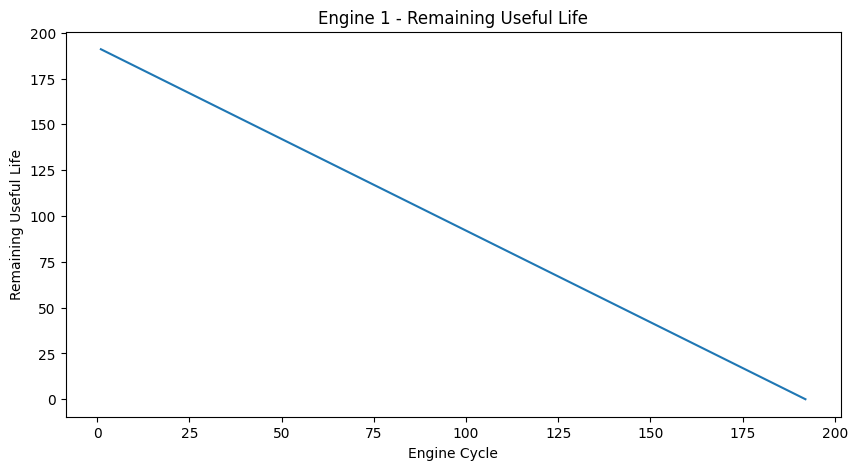

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["RUL"]
)

plt.xlabel("Engine Cycle")
plt.ylabel("Remaining Useful Life")
plt.title("Engine 1 - Remaining Useful Life")

plt.show()

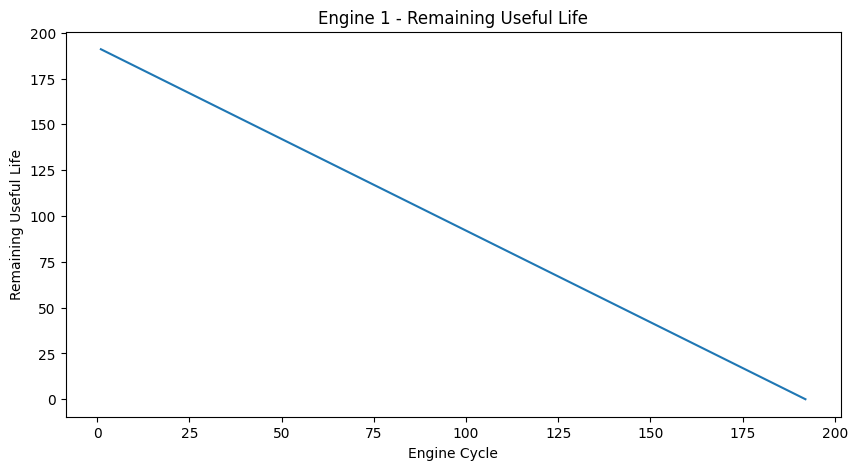

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["RUL"]
)

plt.xlabel("Engine Cycle")
plt.ylabel("Remaining Useful Life")
plt.title("Engine 1 - Remaining Useful Life")

plt.show()

In [ ]:
scaler = MinMaxScaler()

train_df[features] = scaler.fit_transform(
    train_df[features]
)

test_df[features] = scaler.transform(
    test_df[features]
)

In [ ]:
WINDOW_SIZE = 30

In [ ]:
def create_sequences(df, features, target, window_size):

    X = []
    y = []

    for engine_id in df["unit_id"].unique():

        engine = df[df["unit_id"] == engine_id]

        sensor_data = engine[features].values
        rul_data = engine[target].values

        for i in range(len(engine) - window_size):

            X.append(
                sensor_data[i:i + window_size]
            )

            y.append(
                rul_data[i + window_size]
            )

    return np.array(X), np.array(y)

In [ ]:
X, y = create_sequences(
    train_df,
    features,
    target,
    WINDOW_SIZE
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17631, 30, 10)
y shape: (17631,)


In [ ]:
model_basic = Sequential([
    LSTM(
        50,
        input_shape=(WINDOW_SIZE, len(features))
    ),
    Dense(1)
])

model_basic.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_basic.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 50)             │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,251 (47.86 KB)

 Trainable params: 12,251 (47.86 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_basic = model_basic.fit(
    X,
    y,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 9564.1416 - mae: 79.3149 - val_loss: 12583.6738 - val_mae: 88.3265
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 7732.4521 - mae: 69.3894 - val_loss: 10854.5498 - val_mae: 80.5624
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 6505.2393 - mae: 62.8127 - val_loss: 9498.1396 - val_mae: 74.6059
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 5574.8022 - mae: 57.9549 - val_loss: 8431.8965 - val_mae: 70.0381
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 4878.2495 - mae: 54.3511 - val_loss: 7604.2729 - val_mae: 66.5963
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 4370.7729 - mae: 51.8061 - val_loss: 6969.8521 - val_mae: 64.0534
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 4013.6680 - mae: 50.0812 - val_loss: 6493.3062 - val_mae: 62.2290
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 3773.0425 - mae: 49.0091 - val_loss: 6145.6006 -

In [ ]:
pred_basic = model_basic.predict(
    X[:100],
    verbose=0
)

print("Actual RUL:", y[:10])
print("Predicted RUL:", pred_basic[:10].flatten())

Actual RUL: [161 160 159 158 157 156 155 154 153 152]
Predicted RUL: [82.142876 82.14268  82.142914 82.142914 82.14273  82.14285  82.14269
 82.14257  82.14281  82.14241 ]


Stacked LSTM


In [ ]:
return_sequences=True

In [ ]:
model_stacked = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(WINDOW_SIZE, len(features))
    ),

    LSTM(32),

    Dense(1)
])

model_stacked.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_stacked.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_stacked = model_stacked.fit(
    X,
    y,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 9962.3398 - mae: 81.4879 - val_loss: 13509.3896 - val_mae: 92.5571
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 8712.6543 - mae: 74.7117 - val_loss: 12285.0215 - val_mae: 86.9721
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 7780.4326 - mae: 69.6647 - val_loss: 11230.1582 - val_mae: 82.2319
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 6986.1792 - mae: 65.4148 - val_loss: 10310.5029 - val_mae: 78.1570
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 6307.4058 - mae: 61.7762 - val_loss: 9509.9482 - val_mae: 74.6574
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 5729.8682 - mae: 58.7513 - val_loss: 8810.7451 - val_mae: 71.6469
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 5242.6377 - mae: 56.2042 - val_loss: 8209.7441 - val_mae: 69.1033
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 4834.9863 - mae: 54.1219 - val_loss: 7688.2

In [ ]:
model_bi = Sequential([
    Bidirectional(
        LSTM(
            50,
            input_shape=(WINDOW_SIZE, len(features))
        )
    ),

    Dense(32, activation="relu"),

    Dense(1)
])

model_bi.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_bi.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_bi = model_bi.fit(
    X,
    y,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 5831.7915 - mae: 59.8832 - val_loss: 5388.4741 - val_mae: 58.7598
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 3422.5493 - mae: 48.0262 - val_loss: 5419.6978 - val_mae: 58.8141
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 3421.2783 - mae: 47.9960 - val_loss: 5359.9648 - val_mae: 58.6765
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 3398.5171 - mae: 47.8469 - val_loss: 5366.7773 - val_mae: 58.3502
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 2390.6475 - mae: 38.7523 - val_loss: 2509.7205 - val_mae: 37.3456
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 1311.4991 - mae: 26.4203 - val_loss: 2237.8438 - val_mae: 33.3187
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 1088.8617 - mae: 23.1228 - val_loss: 2144.2920 - val_mae: 31.3737
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 1021.4310 - mae: 21.9568 - val_loss: 2148.5571 -

In [ ]:
model_multi = Sequential([
    LSTM(
        64,
        input_shape=(30, 10)
    ),

    Dense(1)
])

model_multi.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_multi.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,265 (75.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_multi = model_multi.fit(
    X,
    y,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 9229.3057 - mae: 77.5077 - val_loss: 11914.3086 - val_mae: 85.2979
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 7087.6470 - mae: 65.9553 - val_loss: 9952.2861 - val_mae: 76.5860
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 5766.9268 - mae: 58.9607 - val_loss: 8515.0273 - val_mae: 70.3889
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 4858.3198 - mae: 54.2677 - val_loss: 7480.6606 - val_mae: 66.0930
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 4254.6226 - mae: 51.2540 - val_loss: 6751.2378 - val_mae: 63.2043
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 3874.5989 - mae: 49.4596 - val_loss: 6253.2949 - val_mae: 61.3517
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 3648.5317 - mae: 48.4918 - val_loss: 5919.0566 - val_mae: 60.2023
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 3525.9871 - mae: 48.0633 - val_loss: 5707.3877 - 

In [ ]:
model_many_to_one = Sequential([
    LSTM(
        50,
        input_shape=(30, 10)
    ),

    Dense(1)
])

model_many_to_one.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_many_to_one.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 50)             │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,251 (47.86 KB)

 Trainable params: 12,251 (47.86 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_many_to_one = model_many_to_one.fit(
    X,
    y,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 9599.3662 - mae: 79.5274 - val_loss: 12627.1426 - val_mae: 88.5241
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 7770.9067 - mae: 69.6210 - val_loss: 10893.2588 - val_mae: 80.7334
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 6534.8652 - mae: 62.9854 - val_loss: 9537.3926 - val_mae: 74.7772
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 5604.3521 - mae: 58.0671 - val_loss: 8476.1074 - val_mae: 70.2246
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 4908.2944 - mae: 54.4975 - val_loss: 7643.8672 - val_mae: 66.7571
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 4398.7661 - mae: 51.9700 - val_loss: 7008.9067 - val_mae: 64.2064
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 4038.0344 - mae: 50.2059 - val_loss: 6530.3262 - val_mae: 62.3669
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 3791.4065 - mae: 49.0963 - val_loss: 6176.7744 -

In [ ]:
return_sequences=True

In [ ]:
model_many_to_many = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(30, 10)
    ),

    Dense(1)
])

model_many_to_many.compile(
    optimizer="adam",
    loss="mse"
)

model_many_to_many.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 30, 1)          │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265 (75.25 KB)

 Trainable params: 19,265 (75.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def create_many_to_many_sequences(
    df,
    features,
    target,
    window_size
):

    X = []
    y = []

    for engine_id in df["unit_id"].unique():

        engine = df[df["unit_id"] == engine_id]

        sensor_data = engine[features].values
        rul_data = engine[target].values

        for i in range(len(engine) - window_size + 1):

            X.append(
                sensor_data[i:i + window_size]
            )

            y.append(
                rul_data[i:i + window_size]
            )

    return np.array(X), np.array(y)

In [ ]:
X_mtm, y_mtm = create_many_to_many_sequences(
    train_df,
    features,
    target,
    30
)

print("X:", X_mtm.shape)
print("Y:", y_mtm.shape)

X: (17731, 30, 10)
Y: (17731, 30)


In [ ]:
history_mtm = model_many_to_many.fit(
    X_mtm,
    y_mtm,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 11944.0420 - val_loss: 14802.2305
Epoch 2/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 9257.4658 - val_loss: 12301.9258
Epoch 3/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 7475.5557 - val_loss: 10419.1699
Epoch 4/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 6171.1904 - val_loss: 8988.3652
Epoch 5/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 5237.5273 - val_loss: 7925.0010
Epoch 6/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 4593.2642 - val_loss: 7152.1797
Epoch 7/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 4168.9624 - val_loss: 6610.1206
Epoch 8/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 3903.2759 - val_loss: 6234.7300
Epoch 9/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 3746.6594 - val_loss: 5984.8911
Epoch 10/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 3660.6750 - val_loss: 5818.7910


In [ ]:
model_autoencoder = Sequential([

    # Encoder
    LSTM(
        64,
        input_shape=(30, 10)
    ),

    # Convert vector back to sequence
    RepeatVector(30),

    # Decoder
    LSTM(
        64,
        return_sequences=True
    ),

    # Reconstruct each sensor feature
    TimeDistributed(
        Dense(10)
    )
])

model_autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

model_autoencoder.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 10)         │           650 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,874 (206.54 KB)

 Trainable params: 52,874 (206.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_autoencoder = model_autoencoder.fit(
    X,
    X,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - loss: 0.0143 - val_loss: 0.0046
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 0.0051 - val_loss: 0.0045
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.0050 - val_loss: 0.0044
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 0.0050 - val_loss: 0.0044
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 0.0050 - val_loss: 0.0044
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 0.0050 - val_loss: 0.0044
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 0.0049 - val_loss: 0.0044
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 0.0049 - val_loss: 0.0044
Epoch 9/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 0.0049 - val_loss: 0.0043
Epoch 10/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 0.0049 - val_loss: 0.0043


In [ ]:
X

array([[[0.        , 0.18373494, 0.40680183, ..., 0.24242424,
         0.109755  , 0.36904762],
        [0.        , 0.28313253, 0.4530194 , ..., 0.21212121,
         0.1002423 , 0.38095238],
        [0.        , 0.34337349, 0.36952256, ..., 0.27272727,
         0.14004308, 0.25      ],
        ...,
        [0.        , 0.34337349, 0.25724875, ..., 0.33333333,
         0.126133  , 0.33333333],
        [0.        , 0.21084337, 0.30063222, ..., 0.22727273,
         0.12895989, 0.23214286],
        [0.        , 0.29819277, 0.49008066, ..., 0.25757576,
         0.10719734, 0.32738095]],

       [[0.        , 0.28313253, 0.4530194 , ..., 0.21212121,
         0.1002423 , 0.38095238],
        [0.        , 0.34337349, 0.36952256, ..., 0.27272727,
         0.14004308, 0.25      ],
        [0.        , 0.34337349, 0.25615871, ..., 0.31818182,
         0.12451763, 0.16666667],
        ...,
        [0.        , 0.21084337, 0.30063222, ..., 0.22727273,
         0.12895989, 0.23214286],
        [0. 

In [ ]:
reconstructed = model_autoencoder.predict(
    X[:100],
    verbose=0
)

reconstruction_error = np.mean(
    np.square(X[:100] - reconstructed),
    axis=(1, 2)
)

print(reconstruction_error[:10])

[0.00320961 0.00314459 0.00311382 0.00316735 0.00319077 0.00318397
 0.00326407 0.00335044 0.00340035 0.00343562]


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

text = """
the engine is operating normally
the engine sensor values are changing
the engine condition is degrading
the engine requires maintenance
the sensor detects abnormal behavior
"""

In [ ]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary size:", total_words)

Vocabulary size: 17


In [ ]:
input_sequences = []

for line in text.split("\n"):

    if line.strip() == "":
        continue

    token_list = tokenizer.texts_to_sequences(
        [line]
    )[0]

    for i in range(1, len(token_list)):

        input_sequences.append(
            token_list[:i + 1]
        )


In [ ]:
max_sequence_length = max(
    len(sequence)
    for sequence in input_sequences
)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_length,
    padding="pre"
)

X_text = input_sequences[:, :-1]
y_text = input_sequences[:, -1]

print("X shape:", X_text.shape)
print("y shape:", y_text.shape)

X shape: (20, 5)
y shape: (20,)


In [ ]:
model_text = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=64
    ),

    LSTM(64),

    Dense(
        total_words,
        activation="softmax"
    )
])

model_text.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_text.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_text = model_text.fit(
    X_text,
    y_text,
    epochs=100,
    verbose=0
)

print("Text LSTM training completed.")

Text LSTM training completed.


In [ ]:
model_dropout = Sequential([
    LSTM(
        64,
        input_shape=(30, 10)
    ),

    Dropout(0.2),

    Dense(
        32,
        activation="relu"
    ),

    Dense(1)
])

model_dropout.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_dropout.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_dropout = model_dropout.fit(
    X,
    y,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 6400.2563 - mae: 62.9071 - val_loss: 5541.7510 - val_mae: 59.0888
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 3464.0024 - mae: 48.2442 - val_loss: 5430.0337 - val_mae: 58.8322
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 3458.2776 - mae: 48.1694 - val_loss: 5380.0176 - val_mae: 58.7369
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 3451.6572 - mae: 48.1452 - val_loss: 5411.2515 - val_mae: 58.7488
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 3102.7363 - mae: 44.9350 - val_loss: 3961.2256 - val_mae: 44.2270
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1437.0229 - mae: 27.2105 - val_loss: 2623.5977 - val_mae: 35.0241
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1213.6698 - mae: 24.4301 - val_loss: 2978.6816 - val_mae: 36.3257
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 1100.4906 - mae: 22.9771 - val_loss: 2284.3877 - v

In [ ]:
predictions = model_basic.predict(
    X,
    verbose=0
).flatten()

mae = mean_absolute_error(
    y,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y,
        predictions
    )
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 50.27901077270508
RMSE: 62.75852586190481


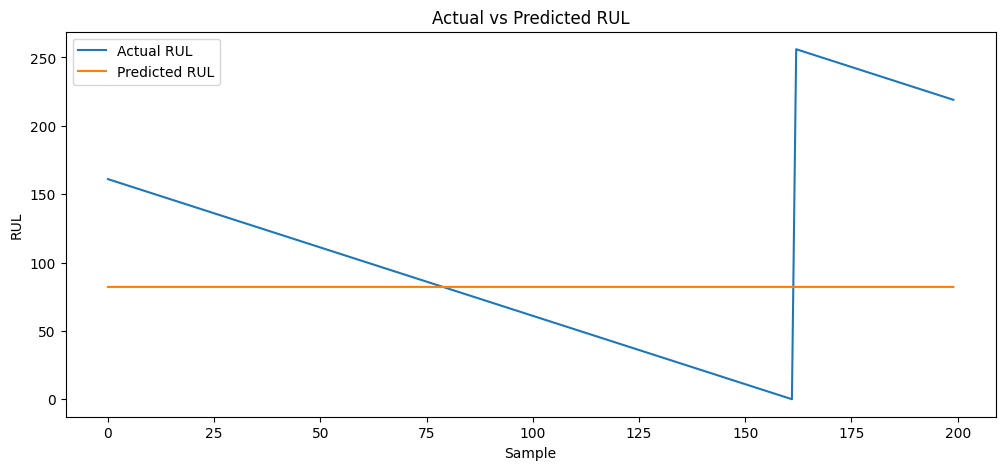

In [ ]:

plt.figure(figsize=(12, 5))

plt.plot(
    y[:200],
    label="Actual RUL"
)

plt.plot(
    predictions[:200],
    label="Predicted RUL"
)

plt.xlabel("Sample")
plt.ylabel("RUL")
plt.title("Actual vs Predicted RUL")

plt.legend()
plt.show()